# Which historical method predicted later JFK Octobers most reliably?

This is a **retrospective chronological test** of October HDD65 using revised GHCN observations from one retained source snapshot. It is not a reconstruction of information published in each historical year. Every prediction uses only earlier complete Octobers, starting in 2000. Collection, live forecasts, and the existing historical payout analysis are separate workflows.

**The key limitation: the 20-year method has only six test years (2020–2025) in the default run.** We show each method's available period and exact common-year comparisons. These overlapping, small samples cannot establish a statistically reliable winner.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import baseline_backtest as backtest
from historical_payout_analysis import write_results

config = backtest.Config(as_of='2026-09-21T00:30:00Z', min_training_years=10, strike=None)
result = backtest.analyze(config)  # Offline: validated retained GHCN snapshot only.
write_results(result, Path('data/baseline_backtest'))
scores = result['scores']
base = scores[scores.method.isin(backtest.METHODS)]
colors = dict(zip(backtest.METHODS, ['#276FBF', '#D17C00', '#7A5195', '#20856A']))
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.spines.top': False, 'axes.spines.right': False})
display(pd.Series(result['manifest']['input_provenance'], name='Retained source'))
print(result['manifest']['analysis'])

/Users/stevenxu/Documents/ChatGPT/Weather Derivative/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


source                                                     GHCN-Daily
station                                                   USW00094789
receipt_id                                   e8e5ff762a1a94e28f53c7df
raw_file            data/raw/ghcn/20260920T033052159252Z_39c80c_US...
retrieved_at_utc                     2026-09-20T03:30:52.161805+00:00
sha256              6eeab7003dc78cb5266923f6972c346b67f07fb79047c7...
Name: Retained source, dtype: object

Retrospective chronological tests using revised observations from a retained snapshot


## Four methods and the held-out test

1. **Expanding:** use all complete prior Octobers from the configured start year.
2. **Recent 10:** use the preceding ten calendar years, requiring ten complete Octobers.
3. **Recent 20:** use the preceding twenty calendar years, requiring twenty complete Octobers.
4. **Temperature trend:** fit a straight line to one October average daily-mean temperature per training year. For historical year y and prediction year Y, add `slope × (Y − y)` to each historical daily temperature, then recalculate daily `max(65 − mean °F, 0)` and sum October HDD. This preserves daily variation and annual residuals; it does not force every October to the same mean.

Each historical October has equal scenario weight. The default minimum is ten complete training Octobers; configurable values must be at least two. Window methods require the larger of the minimum and window length, so a minimum above a window's length disables that method. Missing years never extend a window. Fit parameters and the strike use training years only. Advance one calendar year at a time, recording skipped folds as well as scored folds.

The temperature adjustment is a statistical assumption, not proven climate attribution. Observed temperatures are never overwritten.

,year,valid_days,eligible,exclusion_reason
0,2000,31,True,
1,2001,31,True,
2,2002,31,True,
3,2003,31,True,
4,2004,31,True,
5,2005,31,True,
6,2006,31,True,
7,2007,31,True,
8,2008,31,True,
9,2009,31,True,


status,scored,skipped
method,,
expanding,16,11
recent_10,16,11
recent_20,6,21
temperature_trend,16,11


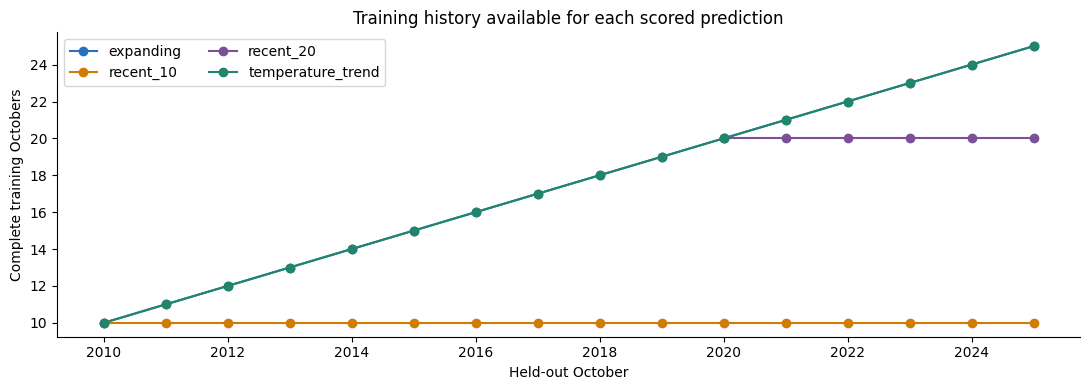

,method,prediction_year,status,training_years,excluded_years,strike,strike_training_years
60,expanding,2010,scored,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],279.285,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
61,recent_10,2010,scored,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],279.285,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
62,recent_20,2010,skipped,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],279.285,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
63,temperature_trend,2010,scored,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],279.285,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
120,expanding,2020,scored,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],241.665,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
121,recent_10,2020,scored,"[2010, 2011, 2012, 2013, 2014, 2015, 2016, 201...",[],241.665,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
122,recent_20,2020,scored,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],241.665,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
123,temperature_trend,2020,scored,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],241.665,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
150,expanding,2025,scored,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[],229.110,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."
151,recent_10,2025,scored,"[2015, 2016, 2017, 2018, 2019, 2020, 2021, 202...",[],229.110,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200..."


In [2]:
display(result['yearly'][['year', 'valid_days', 'eligible', 'exclusion_reason']])
coverage = result['folds'][result['folds'].method.isin(backtest.METHODS)]
display(coverage.groupby(['method', 'status']).size().unstack(fill_value=0))
fig, ax = plt.subplots()
for method in backtest.METHODS:
    f = coverage[(coverage.method == method) & (coverage.status == 'scored')]
    ax.plot(f.prediction_year, f.n_training_years, 'o-', label=method, color=colors[method])
ax.set(xlabel='Held-out October', ylabel='Complete training Octobers', title='Training history available for each scored prediction')
ax.legend(ncol=2); fig.tight_layout(); plt.show()
display(coverage[(coverage.prediction_year.isin([2010, 2020, 2025]))][['method', 'prediction_year', 'status', 'training_years', 'excluded_years', 'strike', 'strike_training_years']])

## Predicted versus realized HDD65

The predicted mean summarizes each empirical distribution. Shaded 10th–90th percentile bands describe **weather-outcome uncertainty**, not uncertainty in estimated forecasting skill. Percentiles use linear interpolation; interval coverage includes its endpoints. Bias is prediction minus observation. CRPS evaluates the full equally weighted empirical distribution; lower is better.

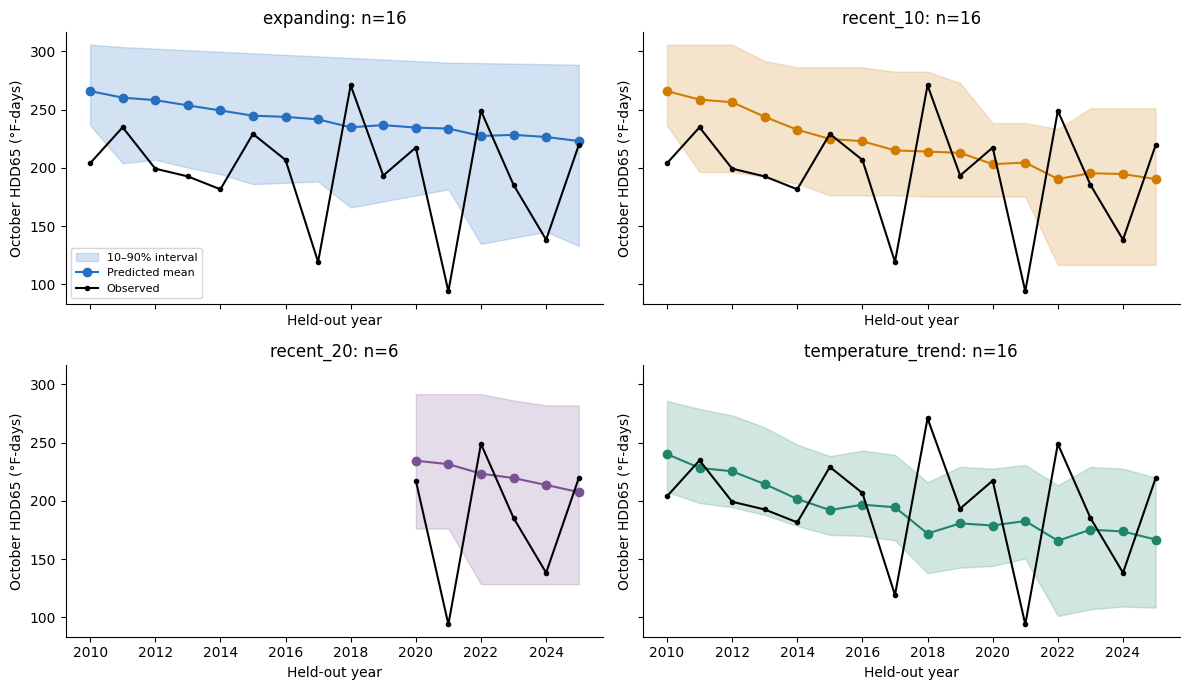

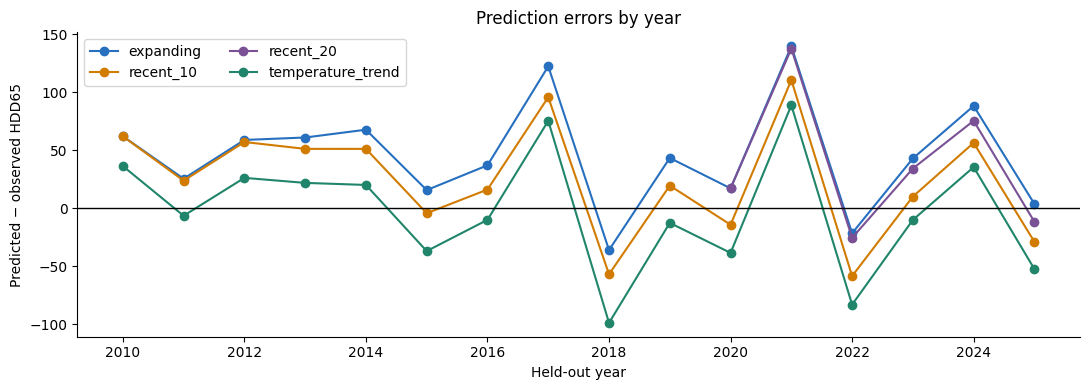

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, method in zip(axes.flat, backtest.METHODS):
    f = base[base.method == method]
    ax.fill_between(f.prediction_year.to_numpy(), f.p10.to_numpy(), f.p90.to_numpy(), alpha=.2, color=colors[method], label='10–90% interval')
    ax.plot(f.prediction_year, f.predicted_mean, 'o-', color=colors[method], label='Predicted mean')
    ax.plot(f.prediction_year, f.realized_hdd, 'k.-', label='Observed')
    ax.set(title=f'{method}: n={len(f)}', ylabel='October HDD65 (°F-days)', xlabel='Held-out year')
axes[0, 0].legend(fontsize=8); fig.tight_layout(); plt.show()
fig, ax = plt.subplots()
for method in backtest.METHODS:
    f = base[base.method == method]
    ax.plot(f.prediction_year, f.error, 'o-', label=method, color=colors[method])
ax.axhline(0, color='black', lw=1)
ax.set(xlabel='Held-out year', ylabel='Predicted − observed HDD65', title='Prediction errors by year')
ax.legend(ncol=2); fig.tight_layout(); plt.show()

## Eligible periods and fair comparisons

The first table uses each method's own eligible period; do not rank its rows as if they cover the same period. The next tables restrict every member of a comparison to the exact intersection of held-out years. Pairwise intersections preserve more data when the 20-year method is not involved. Each test year receives equal weight.

,method,n_test_years,first_test_year,last_test_year,bias,mae,rmse,crps,interval_coverage,interval_width
0,expanding,16,2010,2025,45.412,52.616,64.146,40.596,0.562,117.283
1,recent_10,16,2010,2025,24.374,44.740,53.536,34.318,0.688,103.900
2,recent_20,6,2020,2025,37.795,50.226,66.855,39.174,0.833,143.009
3,temperature_trend,16,2010,2025,-2.840,40.796,50.212,30.452,0.688,86.802


All four methods on exactly the same years — small sample:


,method,n_test_years,first_test_year,last_test_year,bias,mae,rmse,crps,interval_coverage,interval_width
0,expanding,6,2020,2025,44.967,52.155,70.556,41.853,0.667,137.911
1,recent_10,6,2020,2025,12.512,46.408,57.632,34.940,0.667,107.610
2,recent_20,6,2020,2025,37.795,50.226,66.855,39.174,0.833,143.009
3,temperature_trend,6,2020,2025,-10.005,51.375,58.256,36.298,0.667,104.632


Pairwise comparisons:


,comparison,method,n_test_years,first_test_year,last_test_year,bias,mae,rmse,crps,interval_coverage,interval_width
4,expanding + recent_10,expanding,16,2010,2025,45.412,52.616,64.146,40.596,0.562,117.283
5,expanding + recent_10,recent_10,16,2010,2025,24.374,44.740,53.536,34.318,0.688,103.900
6,expanding + recent_20,expanding,6,2020,2025,44.967,52.155,70.556,41.853,0.667,137.911
7,expanding + recent_20,recent_20,6,2020,2025,37.795,50.226,66.855,39.174,0.833,143.009
8,expanding + temperature_trend,expanding,16,2010,2025,45.412,52.616,64.146,40.596,0.562,117.283
9,expanding + temperature_trend,temperature_trend,16,2010,2025,-2.840,40.796,50.212,30.452,0.688,86.802
10,recent_10 + recent_20,recent_10,6,2020,2025,12.512,46.408,57.632,34.940,0.667,107.610
11,recent_10 + recent_20,recent_20,6,2020,2025,37.795,50.226,66.855,39.174,0.833,143.009
12,recent_10 + temperature_trend,recent_10,16,2010,2025,24.374,44.740,53.536,34.318,0.688,103.900
13,recent_10 + temperature_trend,temperature_trend,16,2010,2025,-2.840,40.796,50.212,30.452,0.688,86.802


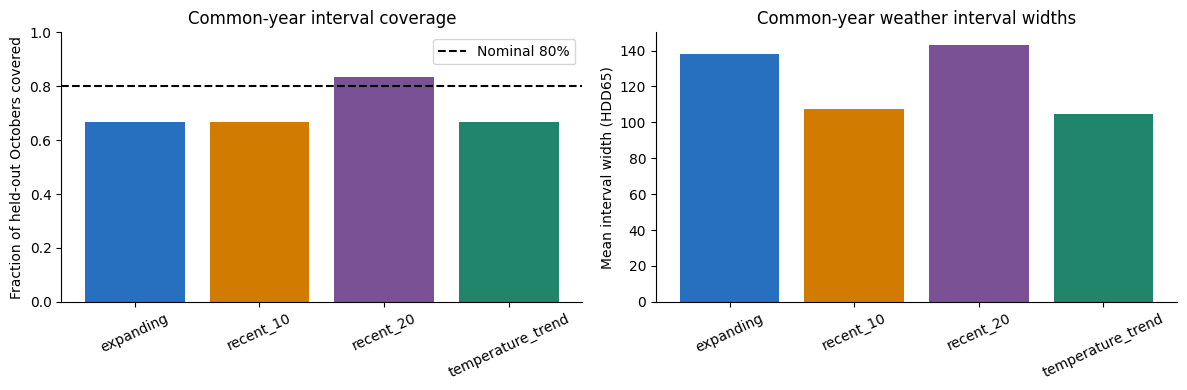

In [4]:
metric_columns = ['method', 'n_test_years', 'first_test_year', 'last_test_year', 'bias', 'mae', 'rmse', 'crps', 'interval_coverage', 'interval_width']
display(result['metrics_individual'][metric_columns].round(3))
common = result['metrics_common']
all_common = common[common.comparison == ' + '.join(backtest.METHODS)]
print('All four methods on exactly the same years — small sample:')
display(all_common[metric_columns].round(3))
print('Pairwise comparisons:')
pairs = common[common.comparison.str.count(r' \+ ') == 1]
display(pairs[['comparison'] + metric_columns].round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(all_common.method, all_common.interval_coverage, color=[colors[m] for m in all_common.method])
axes[0].axhline(.8, color='black', linestyle='--', label='Nominal 80%')
axes[0].set(ylim=(0, 1), ylabel='Fraction of held-out Octobers covered', title='Common-year interval coverage'); axes[0].legend()
axes[1].bar(all_common.method, all_common.interval_width, color=[colors[m] for m in all_common.method])
axes[1].set(ylabel='Mean interval width (HDD65)', title='Common-year weather interval widths')
for ax in axes: ax.tick_params(axis='x', rotation=25)
fig.tight_layout(); plt.show()

## Hypothetical payouts

For each fold the default strike is the median HDD of **all eligible expanding training years**. That identical strike applies to every method and the realized October in that fold. Set `strike` in the configuration for an explicitly supplied fixed strike. The full-sample 224.22 HDD median is never used as an automatically derived historical strike.

Apply `$100 × max(scenario HDD65 − strike, 0)` to **each scenario before averaging**. Positive-payout frequency is the equally weighted fraction exceeding the fold's strike. These are hypothetical payout forecasts, not market prices, premiums, or investment returns.

,method,prediction_year,strike,predicted_average_payout_usd,realized_payout_usd,payout_error_usd,positive_payout_frequency
0,expanding,2010,279.28,892.35,0.0,892.35,0.50
1,recent_10,2010,279.28,892.35,0.0,892.35,0.50
2,temperature_trend,2010,279.28,159.71,0.0,159.71,0.20
4,expanding,2011,276.99,915.55,0.0,915.55,0.45
5,recent_10,2011,276.99,1007.10,0.0,1007.10,0.50
6,temperature_trend,2011,276.99,37.61,0.0,37.61,0.18
8,expanding,2012,268.82,1248.00,0.0,1248.00,0.50
9,recent_10,2012,268.82,1415.85,0.0,1415.85,0.50
10,temperature_trend,2012,268.82,112.12,0.0,112.12,0.17
12,expanding,2013,260.64,1529.31,0.0,1529.31,0.46


,method,n_test_years,payout_bias_usd,payout_mae_usd,payout_rmse_usd
0,expanding,6,1801.90,1801.90,1895.18
1,recent_10,6,170.12,605.53,690.73
2,recent_20,6,1417.08,1417.08,1518.65
3,temperature_trend,6,-177.11,355.78,660.06


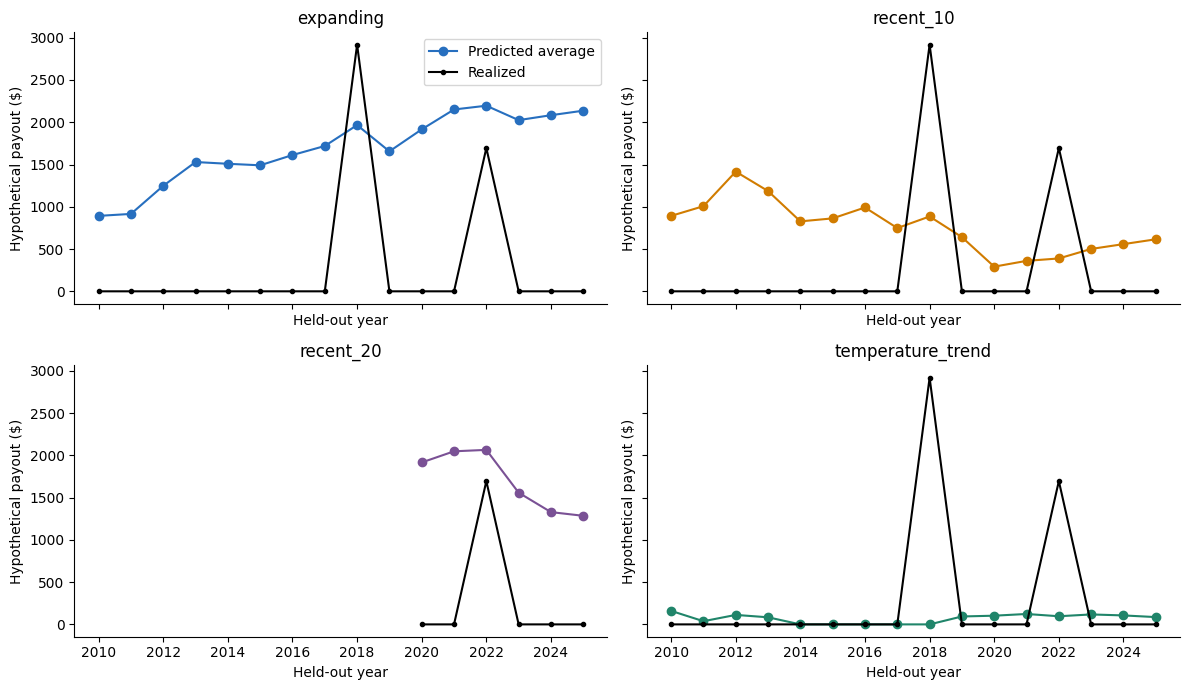

In [5]:
display(base[['method', 'prediction_year', 'strike', 'predicted_average_payout_usd', 'realized_payout_usd', 'payout_error_usd', 'positive_payout_frequency']].round(2))
display(all_common[['method', 'n_test_years', 'payout_bias_usd', 'payout_mae_usd', 'payout_rmse_usd']].round(2))
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, method in zip(axes.flat, backtest.METHODS):
    f = base[base.method == method]
    ax.plot(f.prediction_year, f.predicted_average_payout_usd, 'o-', color=colors[method], label='Predicted average')
    ax.plot(f.prediction_year, f.realized_payout_usd, 'k.-', label='Realized')
    ax.set(title=method, ylabel='Hypothetical payout ($)', xlabel='Held-out year')
axes[0, 0].legend(); fig.tight_layout(); plt.show()

## Sensitivity to history and trend assumptions

The recent-10 versus recent-20 pair above tests the historical-window assumption on the same six years. Two additional, fixed diagnostics halve the expanding trend shift or fit the trend using only the preceding twenty complete calendar years. Compare those with expanding (no shift) and the full expanding trend shift on their shared test years below. These diagnostics are not tuned or selected using test scores. A different slope or fitting period changes the scenario distribution and payout estimates.

In [6]:
sensitivity = common[common.comparison == ' + '.join(('expanding', 'temperature_trend', *backtest.SENSITIVITY))]
display(sensitivity[metric_columns + ['payout_mae_usd']].round(3))
trend_folds = result['folds'].query("status == 'scored' and method == 'temperature_trend'")
display(trend_folds[['prediction_year', 'n_training_years', 'trend_slope_c_per_year', 'target_trend_level_c']].round(4))

,method,n_test_years,first_test_year,last_test_year,bias,mae,rmse,crps,interval_coverage,interval_width,payout_mae_usd
16,expanding,6,2020,2025,44.967,52.155,70.556,41.853,0.667,137.911,1801.899
17,temperature_trend,6,2020,2025,-10.005,51.375,58.256,36.298,0.667,104.632,355.779
18,trend_half_shift,6,2020,2025,16.391,46.775,58.382,34.242,0.833,121.625,701.698
19,trend_recent_20,6,2020,2025,-8.486,51.595,58.560,36.325,0.667,114.311,386.172


,prediction_year,n_training_years,trend_slope_c_per_year,target_trend_level_c
63,2010,10,0.0982,14.3897
69,2011,11,0.1126,14.6031
75,2012,12,0.1067,14.6647
81,2013,13,0.1196,14.8919
87,2014,14,0.1380,15.1954
93,2015,15,0.1446,15.4031
99,2016,16,0.1210,15.2803
105,2017,17,0.1147,15.3258
111,2018,18,0.1497,15.8839
117,2019,19,0.1259,15.7161


## What the results support

The following statements are calculated from this notebook's configuration, rather than a hard-coded ranking. Lower MAE/CRPS in these retained test years is descriptive evidence only. No method is declared a statistically established winner.

In [7]:
individual = result['metrics_individual']
for name, table in [('Each method’s eligible period (not directly comparable)', individual), ('Shared period', all_common)]:
    print(name)
    display(table[['method', 'n_test_years', 'mae', 'crps', 'payout_mae_usd']].round(2))
if len(all_common) and all_common.n_test_years.min() > 0:
    best = all_common.loc[all_common.mae.idxmin()]
    print(f"Lowest descriptive common-year HDD MAE: {best.method}, {best.mae:.2f}, across {int(best.n_test_years)} years.")
print('No statistically established winner; rankings depend on period, metric, and assumptions.')

Each method’s eligible period (not directly comparable)


,method,n_test_years,mae,crps,payout_mae_usd
0,expanding,16,52.62,40.60,1520.84
1,recent_10,16,44.74,34.32,889.83
2,recent_20,6,50.23,39.17,1417.08
3,temperature_trend,16,40.80,30.45,346.20


Shared period


,method,n_test_years,mae,crps,payout_mae_usd
0,expanding,6,52.16,41.85,1801.90
1,recent_10,6,46.41,34.94,605.53
2,recent_20,6,50.23,39.17,1417.08
3,temperature_trend,6,51.38,36.30,355.78


Lowest descriptive common-year HDD MAE: recent_10, 46.41, across 6 years.
No statistically established winner; rankings depend on period, metric, and assumptions.


A nominal 80% weather interval need not cover 80% of a small held-out sample. Only six distinct calendar years are available to compare all four methods; training samples overlap, and annual outcomes may also be serially dependent. No confidence intervals for performance are estimated here. If added later, resampling must use whole years (paired across methods, considering temporal dependence), not individual days. More bootstrap draws do not create more independent historical years.

Station history, nonstationarity, a linear extrapolation assumption, and revised observations limit interpretation. No test-period tuning, climate attribution, market-price inference, or live-ensemble integration is performed.

The output folder preserves every candidate fold (including skips), exact training and excluded years, strike training years, trend coefficients, equally weighted scenarios, annual scores, individual and common-year metrics, QC audit, and a manifest of parameters, source receipt, input/code/output hashes. The original observations and existing workflows are preserved.